# Required package

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns

In [54]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error

# Exercise 3.5.1

$$
y_t = y_i + \sum_{i=1}^{t} \epsilon_t
$$

In [3]:
np.random.seed(42)
y_i=1
y = y_i + st.norm.rvs(size=500).cumsum()

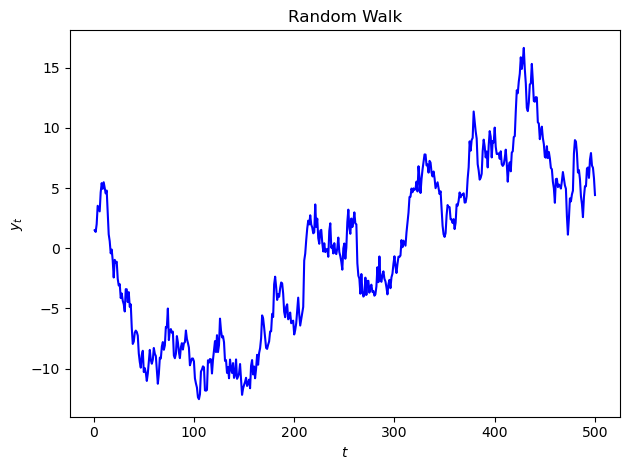

In [4]:
fig, ax = plt.subplots()
ax.plot(np.arange(1, 501), y, 'b-')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
ax.set_title('Random Walk')
plt.tight_layout()
plt.show()

In [5]:
diff_y = np.diff(y)

In [6]:
testing = adfuller(diff_y)
print(testing)

(-22.313025583815026, 0.0, 0, 498, {'1%': -3.4435494520411605, '5%': -2.8673612117611267, '10%': -2.5698704830567247}, 1348.0081385612605)


In [7]:
train = y[:400]
test = y[400:]

In [8]:
drift = (train[-1] - train[0]) / (400 - 1)

In [9]:
pred = pd.DataFrame({
    'observed': test,
    'mean': np.mean(train),
    'last value': train[-1],
    'drift': drift * np.arange(401, 501, 1) + train[0],
    'next step': y[399:499]
}, index = np.arange(400, 500))
pred.head()

,observed,mean,last value,drift,next step
400,8.425017,-2.490667,10.019444,10.062165,10.019444
401,7.825642,-2.490667,10.019444,10.083525,8.425017
402,7.830885,-2.490667,10.019444,10.104885,7.825642
403,7.877866,-2.490667,10.019444,10.126245,7.830885
404,7.427800,-2.490667,10.019444,10.147606,7.877866


In [10]:
mse = pd.Series({
    'mean': mean_squared_error(pred['observed'], pred['mean']),
    'last value': mean_squared_error(pred['observed'], pred['last value']),
    'drift': mean_squared_error(pred['observed'], pred['drift']),
    'next step': mean_squared_error(pred['observed'], pred['next step'])
})

In [11]:
mse

mean          123.931980
last value     15.424511
drift          23.386194
next step       1.123343
dtype: float64

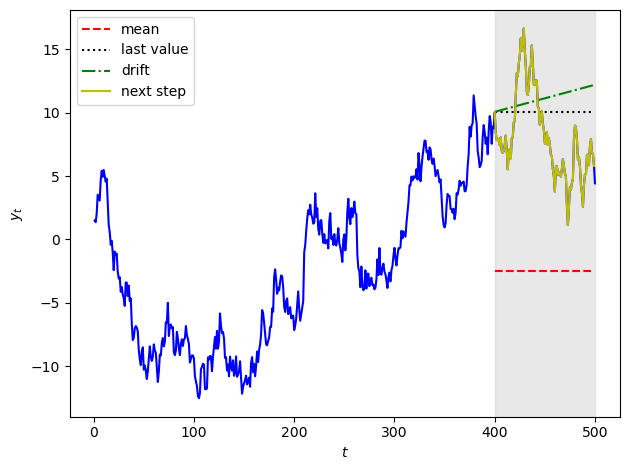

In [12]:
fig, ax = plt.subplots()
ax.plot(np.arange(1, 501, 1), y, 'b-')
ax.plot(pred['mean'], 'r--', label='mean')
ax.plot(pred['last value'], 'k:', label='last value')
ax.plot(pred['drift'], 'g-.', label='drift')
ax.plot(pred['next step'], 'y-', label='next step')
ax.axvspan(400, 500, color='lightgray', alpha=0.5)
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# Exercise 3.5.2

In [13]:
google = pd.read_csv("data/GOOGL.csv")

In [14]:
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


In [15]:
google.set_index('Date', inplace=True)

In [16]:
google.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


In [17]:
google_close = google['Adj Close']
google_close

Date
2020-04-27    1270.859985
2020-04-28    1232.589966
2020-04-29    1342.180054
2020-04-30    1346.699951
2020-05-01    1317.319946
                 ...     
2021-04-21    2278.350098
2021-04-22    2252.520020
2021-04-23    2299.929932
2021-04-26    2309.929932
2021-04-27    2290.979980
Name: Adj Close, Length: 253, dtype: float64

In [18]:
test = google_close[-5:]
train = google_close[:-5]

In [19]:
train.shape

(248,)

In [20]:
drift = (train.iloc[-1] - train.iloc[0]) / 248

In [21]:
df_pred = pd.DataFrame({
    'actual': test,
    'mean': np.mean(train),
    'last value': train.iloc[-1],
    'drift': drift * np.arange(248, 253) + train.iloc[0],
    'next step': google_close.shift(periods=1).iloc[-5:].values
}, index = test.index)

In [22]:
df_pred

,actual,mean,last value,drift,next step
Date,,,,,
2021-04-21,2278.350098,1689.993184,2279.01001,2279.010010,2279.010010
2021-04-22,2252.520020,1689.993184,2279.01001,2283.075131,2278.350098
2021-04-23,2299.929932,1689.993184,2279.01001,2287.140252,2252.520020
2021-04-26,2309.929932,1689.993184,2279.01001,2291.205373,2299.929932
2021-04-27,2290.979980,1689.993184,2279.01001,2295.270494,2309.929932


In [23]:
mse = pd.Series({
    'mean': mean_squared_error(df_pred['actual'], df_pred['mean']),
    'last value': mean_squared_error(df_pred['actual'], df_pred['last value']),
    'drift': mean_squared_error(df_pred['actual'], df_pred['drift']),
    'next step': mean_squared_error(df_pred['actual'], df_pred['next step']),
})
mse

mean          356025.967015
last value       447.823990
drift            293.328764
next step        674.885770
dtype: float64

In [72]:
google_close.index

Index(['2020-04-27', '2020-04-28', '2020-04-29', '2020-04-30', '2020-05-01',
       '2020-05-04', '2020-05-05', '2020-05-06', '2020-05-07', '2020-05-08',
       ...
       '2021-04-14', '2021-04-15', '2021-04-16', '2021-04-19', '2021-04-20',
       '2021-04-21', '2021-04-22', '2021-04-23', '2021-04-26', '2021-04-27'],
      dtype='object', name='Date', length=253)

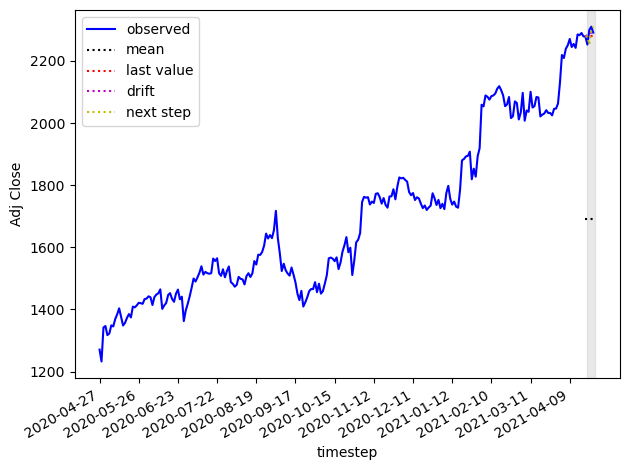

In [24]:
fig, ax = plt.subplots()
ax.plot(google_close, 'b-', label='observed')
ax.plot(df_pred['mean'], 'k:', label='mean')
ax.plot(df_pred['last value'], 'r:', label='last value')
ax.plot(df_pred['drift'], 'm:', label='drift')
ax.plot(df_pred['next step'], 'y:', label='next step')
ax.set_xlabel('timestep')
ax.set_xticks(google_close.index[np.arange(0, 253, 20)])
ax.axvspan(249, 253, color='lightgray', alpha=0.5)
ax.set_ylabel('Adj Close')
ax.legend(loc='best')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Exercise 3.5.3

Download time series: https://stockquote.io/ 

In [44]:
pbr = (
    pd.read_csv("data/pbr_data.csv", parse_dates=['DATE'])
    .set_index('DATE')
    .sort_index()
)

In [45]:
pbr.head()

,OPEN,HIGH,LOW,CLOSE,ADJ CLOSE,VOLUME
DATE,,,,,,
2025-02-12,13.80,13.86,13.62,13.69,12.75,13678900
2025-02-13,13.50,13.75,13.49,13.71,12.77,9945100
2025-02-14,13.95,14.45,13.92,14.32,13.34,20755600
2025-02-18,14.58,14.85,14.56,14.76,13.75,19504800
2025-02-19,14.76,14.98,14.76,14.83,13.81,13178600


In [46]:
pbr.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2025-02-12 to 2026-02-12
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   OPEN       252 non-null    float64
 1   HIGH       252 non-null    float64
 2   LOW        252 non-null    float64
 3   CLOSE      252 non-null    float64
 4   ADJ CLOSE  252 non-null    float64
 5   VOLUME     252 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.8 KB


In [47]:
pbr.index

DatetimeIndex(['2025-02-12', '2025-02-13', '2025-02-14', '2025-02-18',
               '2025-02-19', '2025-02-20', '2025-02-21', '2025-02-24',
               '2025-02-25', '2025-02-26',
               ...
               '2026-01-30', '2026-02-02', '2026-02-03', '2026-02-04',
               '2026-02-05', '2026-02-06', '2026-02-09', '2026-02-10',
               '2026-02-11', '2026-02-12'],
              dtype='datetime64[ns]', name='DATE', length=252, freq=None)

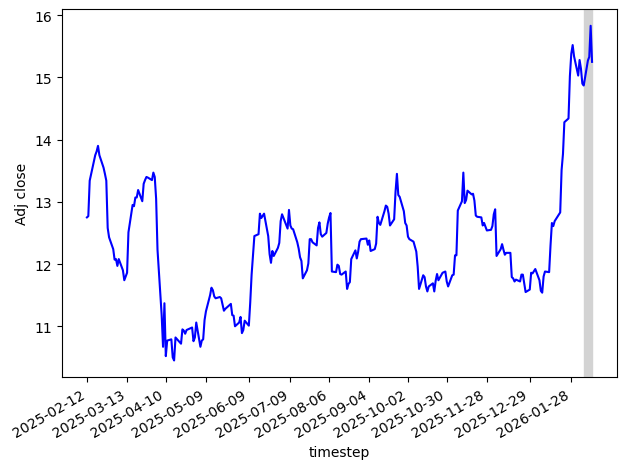

In [75]:
fig, ax = plt.subplots()
ax.plot(pbr['ADJ CLOSE'], 'b-')
ax.set_xlabel('timestep')
ax.set_ylabel('Adj close')
ax.set_xticks(
    pbr.index[np.arange(0, 260, 20)]
)
ax.axvspan(
    pbr.index[-5], pbr.index[-1], color='lightgray'
)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [51]:
adfuller(pbr['ADJ CLOSE'])

(-2.0233550467788466,
 0.2764275325005634,
 2,
 249,
 {'1%': -3.4568881317725864,
  '5%': -2.8732185133016057,
  '10%': -2.5729936189738876},
 14.306763307696826)

In [52]:
pbr_diff = np.diff(pbr['ADJ CLOSE'])

In [53]:
adfuller(pbr_diff)

(-9.193272038578643,
 2.0953130189864853e-15,
 1,
 249,
 {'1%': -3.4568881317725864,
  '5%': -2.8732185133016057,
  '10%': -2.5729936189738876},
 15.294443567387532)

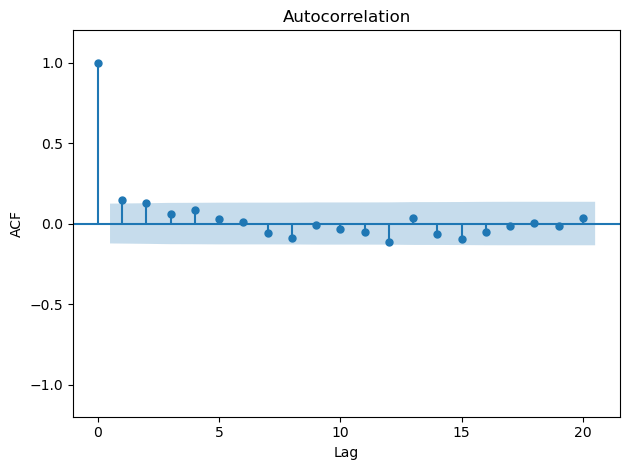

In [56]:
fig, ax = plt.subplots()
plot_acf(pbr_diff, lags=20, ax=ax)
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_ylim([-1.2, 1.2])
plt.tight_layout()
plt.show()

In [57]:
train = pbr['ADJ CLOSE'].iloc[:-5].copy()

In [58]:
test = pbr['ADJ CLOSE'].iloc[-5:].copy()

In [59]:
train.shape

(247,)

In [60]:
drift = (train.iloc[-1] - train.iloc[0]) / 247

In [61]:
pbr.shape

(252, 6)

In [62]:
df_pred = pd.DataFrame({
    'actual': test,
    'mean': np.mean(train),
    'last value': train.iloc[-1],
    'drift': drift * np.arange(247, 252) + train.iloc[0],
    'next step': pbr['ADJ CLOSE'].shift(periods=1).iloc[-5:].values
}, index = test.index)

In [63]:
df_pred

,actual,mean,last value,drift,next step
DATE,,,,,
2026-02-06,14.87,12.280405,14.9,14.900000,14.90
2026-02-09,15.27,12.280405,14.9,14.908704,14.87
2026-02-10,15.33,12.280405,14.9,14.917409,15.27
2026-02-11,15.83,12.280405,14.9,14.926113,15.33
2026-02-12,15.25,12.280405,14.9,14.934818,15.83


In [64]:
mse = pd.Series({
    'mean': mean_squared_error(df_pred['actual'], df_pred['mean']),
    'last value': mean_squared_error(df_pred['actual'], df_pred['last value']),
    'drift': mean_squared_error(df_pred['actual'], df_pred['drift']),
    'next step': mean_squared_error(df_pred['actual'], df_pred['next step']),
})
mse

mean          9.272367
last value    0.262020
drift         0.243603
next step     0.150180
dtype: float64

In [69]:
pbr.shape

(252, 6)

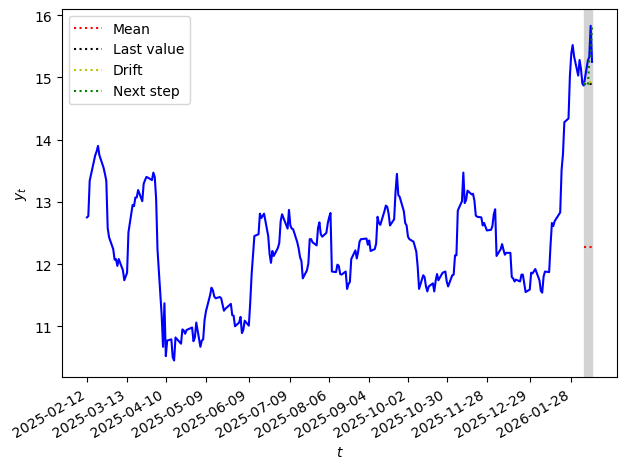

In [83]:
fig, ax = plt.subplots()
ax.plot(pbr['ADJ CLOSE'], 'b-')
ax.set_ylabel('$y_t$')
ax.set_xlabel('$t$')
ax.set_xticks(
    pbr.index[np.arange(0, 260, 20)]
)
ax.axvspan(
    pbr.index[-5], pbr.index[-1], color='lightgray'
)
ax.plot(df_pred['mean'], 'r:', label='Mean')
ax.plot(df_pred['last value'], 'k:', label='Last value')
ax.plot(df_pred['drift'], 'y:', label='Drift')
ax.plot(df_pred['next step'], 'g:', label='Next step')
ax.legend(loc='best')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()